# Processamento Digital de Imagem: Hidden Letters

## Identificação do Grupo
- **Alex Martins** — **PG61508**
- **Miguel Machado** — **PG60284**
- **Paulo Ferreira** — **PG60288**

## Introdução
Este notebook documenta o processo de exploração, desenvolvimento e refinamento de um pipeline para restaurar a imagem degradada `Letters-noisy.png`, com o objetivo de recuperar o texto oculto. Ao longo do trabalho, foram testadas diferentes abordagens no domínio da frequência e no domínio espacial, avaliando o impacto de cada técnica na remoção de ruído e na preservação da legibilidade das letras.

O notebook está organizado em duas fases principais:
- uma **primeira iteração**, correspondente à abordagem exploratória inicial;
- uma **segunda iteração**, mais completa e refinada, que consolida as melhorias introduzidas após a análise dos resultados obtidos.


---

# Primeira Iteração: Exploração Inicial

## Resumo
Nesta primeira abordagem, o foco principal foi identificar as diferentes componentes de ruído presentes na imagem e testar uma estratégia inicial de restauração. A análise mostrou que a imagem apresentava, simultaneamente, **ruído periódico** e **ruído aleatório**, o que exigiu uma combinação de técnicas no domínio da frequência e no domínio espacial.

## Metodologia
A metodologia seguida nesta fase consistiu em:
1. carregar e inspecionar a imagem original;
2. analisar o espetro de magnitude através da DFT;
3. detetar automaticamente picos correspondentes ao ruído periódico;
4. aplicar filtros notch gaussianos para atenuar essas frequências;
5. remover o ruído residual do tipo *salt & pepper* com filtro de mediana;
6. testar uma segmentação final através de binarização adaptativa e deteção de contornos.



### Passo 0: Importações e Inicializações
(Nesta secção, carregamos as bibliotecas necessárias e a imagem original degradada.)

In [1]:
import cv2

import numpy as np
from matplotlib import pyplot as plt

# Configuração para exibir plots no notebook
%matplotlib inline

# Configurações de plot para melhor visualização
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['image.cmap'] = 'gray'

### Passo 1. Configuração de Parâmetros
Definição centralizada de parâmetros para facilitar a experimentação.

In [2]:
INPUT_IMAGE_PATH = '../assets/Letters-noisy.png'

# Parâmetros de Thresholding Espetral
THRESHOLD_STRONG = 170
THRESHOLD_WEAK = 150

# Raios dos Filtros Notch Gaussianos
RADIUS_STRONG = 6
RADIUS_WEAK = 3

# Filtro de Mediana
MEDIAN_KERNEL_SIZE = 3

# Binarização Adaptativa
ADAPTIVE_BLOCK_SIZE = 221
ADAPTIVE_C = 15

# Detecção de Bordas (Canny)
CANNY_LOW = 100
CANNY_HIGH = 200

### Passo 2: Aquisição e Inspeção Inicial

O primeiro passo consiste em carregar a imagem em escala de cinza. A visualização da mesma é crucial para identificar que o ruído periódico é a degradação mais estruturada, sugerindo que deve ser a primeira a ser tratada através de filtragem espetral.

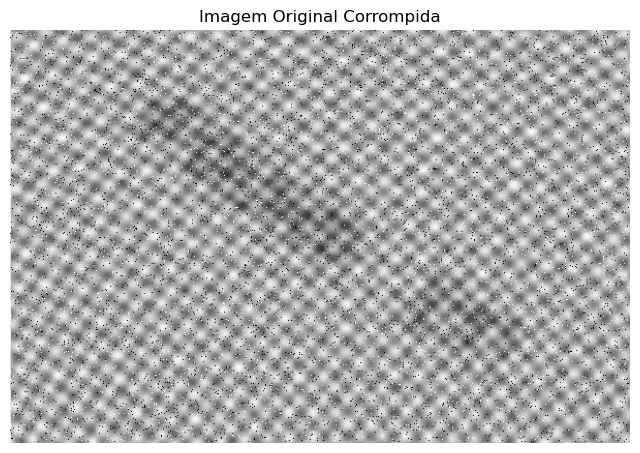

In [3]:
img_original = cv2.imread(INPUT_IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print(f"Erro: Não foi possível carregar a imagem em '{INPUT_IMAGE_PATH}'.")
else:
    plt.imshow(img_original)
    plt.title('Imagem Original Corrompida')
    plt.axis('off')
    plt.show()

### Passo 3: Transformada Discreta de Fourier (DFT)

Para isolar o ruído periódico, convertemos a imagem do domínio espacial para o domínio da frequência. 

**Porquê?** Padrões repetitivos no espaço transformam-se em picos de alta energia (pontos brilhantes) em frequências específicas no espetro de magnitude. Ao aplicar o `fftshift`, colocamos a frequência zero (DC) no centro, facilitando a identificação simétrica das interferências.

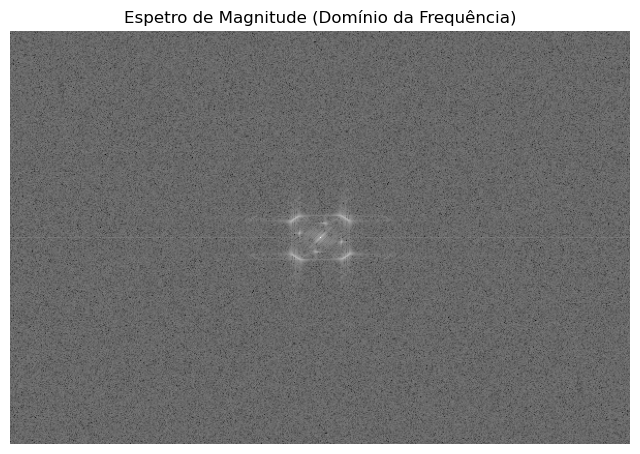

In [4]:
dft = cv2.dft(np.float32(img_original), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

plt.imshow(magnitude_spectrum)
plt.title('Espetro de Magnitude (Domínio da Frequência)')
plt.axis('off')
plt.show()

### Passo 4: Identificação Automática de Picos (Thresholding Espetral)

Em vez de remover os picos manualmente, aplicamos limiares (thresholds) no espetro de magnitude. 
- Os **Picos Fortes** são as frequências dominantes do ruído.
- Os **Picos Fracos** são harmónicas secundárias.

Isolar estes pontos permite-nos saber exatamente onde colocar os filtros notch.

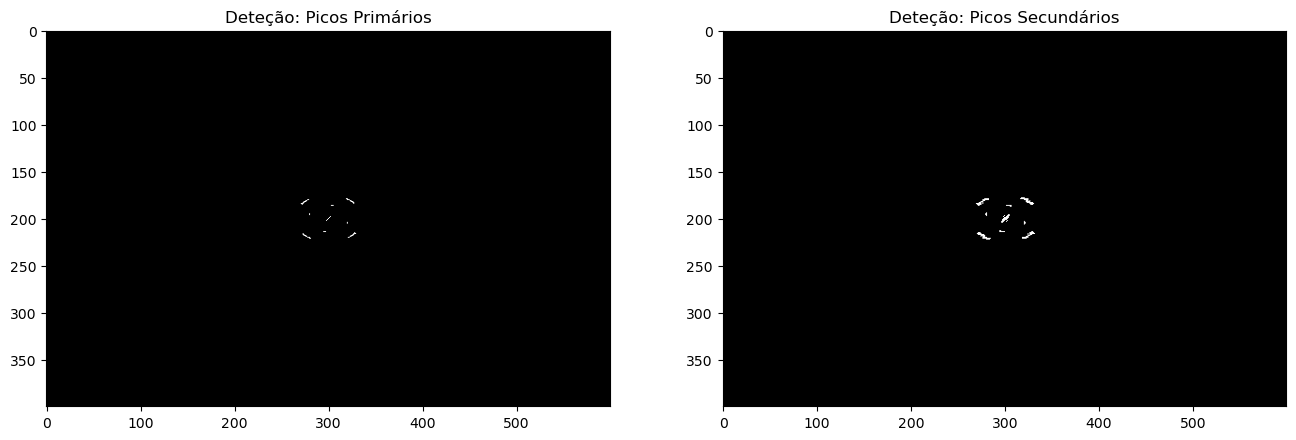

In [5]:
norm_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
_, picos_fortes_img = cv2.threshold(norm_spectrum, THRESHOLD_STRONG, 255, cv2.THRESH_BINARY)
_, picos_fracos_img = cv2.threshold(norm_spectrum, THRESHOLD_WEAK, 255, cv2.THRESH_BINARY)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.imshow(picos_fortes_img)
ax1.set_title('Deteção: Picos Primários')
ax2.imshow(picos_fracos_img)
ax2.set_title('Deteção: Picos Secundários')
plt.show()

### Passo 5: Filtro Notch Gaussiano

Um filtro Notch ideal (que corta a frequência abruptamente), como aqueles lecionados em aula, podem introduzir o efeito de *ringing* (oscilações) na imagem reconstruída. 

**A nossa abordagem:** Utilizamos filtros Notch com decaimento **Gaussiano**. Isso garante uma transição mais suave entre as frequências rejeitadas e as preservadas, resultando numa imagem mais natural. Aplicamos raios maiores para picos fortes e raios menores para picos subtis, otimizando a relação sinal-ruído.

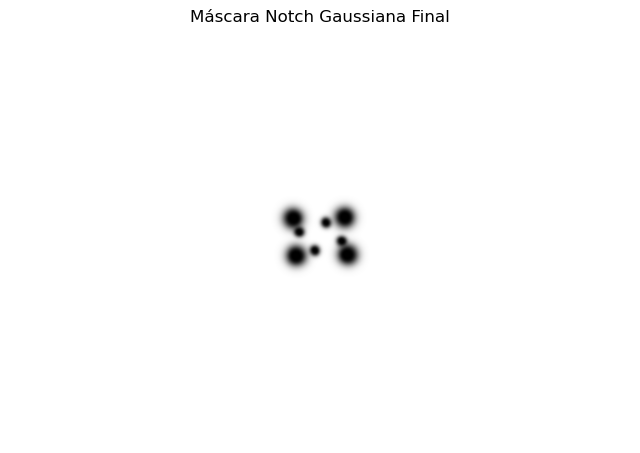

In [6]:
def criar_mascara_notch_gaussiana(shape, picos_img, raio, mascara_existente=None):
    if mascara_existente is None: mascara = np.ones(shape, dtype=np.float32)
    else: mascara = mascara_existente.copy().astype(np.float32) / (255.0 if mascara_existente.dtype == np.uint8 else 1.0)
    
    contours, _ = cv2.findContours(picos_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    crow, ccol = shape[0] // 2, shape[1] // 2
    Y, X = np.ogrid[:shape[0], :shape[1]]
    
    for cnt in contours:
        M = cv2.moments(cnt)
        if M["m00"] == 0: continue
        cX, cY = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
        if np.sqrt((cX - ccol)**2 + (cY - crow)**2) > 5:
            dist_sq_1 = (X - cX)**2 + (Y - cY)**2
            notch_1 = 1.0 - np.exp(-dist_sq_1 / (2 * (raio**2)))
            sym_X, sym_Y = (2 * ccol) - cX, (2 * crow) - cY
            dist_sq_2 = (X - sym_X)**2 + (Y - sym_Y)**2
            notch_2 = 1.0 - np.exp(-dist_sq_2 / (2 * (raio**2)))
            mascara = mascara * notch_1 * notch_2
    return mascara

rows, cols = img_original.shape
mascara_notch = criar_mascara_notch_gaussiana((rows, cols), picos_fortes_img, RADIUS_STRONG)
mascara_notch = criar_mascara_notch_gaussiana((rows, cols), picos_fracos_img, RADIUS_WEAK, mascara_existente=mascara_notch)
mascara_final = np.stack([mascara_notch, mascara_notch], axis=-1)

plt.imshow(mascara_notch)
plt.title('Máscara Notch Gaussiana Final')
plt.axis('off')
plt.show()

### Passo 6: Reconstrução no Domínio Espacial

Multiplicamos o espetro da imagem original pela máscara notch e aplicamos a **Transformada Inversa de Fourier (IDFT)**. O resultado é a imagem livre das linhas periódicas, revelando o texto oculto, embora ainda apresente ruído granular (Salt & Pepper).

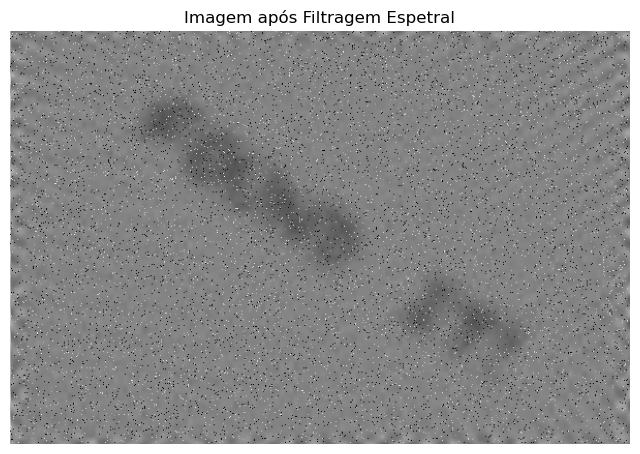

In [7]:
fshift_filtrado = dft_shift * mascara_final
f_ishift = np.fft.ifftshift(fshift_filtrado)
img_filtrada_freq = cv2.idft(f_ishift)
img_filtrada_freq = cv2.magnitude(img_filtrada_freq[:, :, 0], img_filtrada_freq[:, :, 1])
cv2.normalize(img_filtrada_freq, img_filtrada_freq, 0, 255, cv2.NORM_MINMAX)
img_filtrada_freq = np.uint8(img_filtrada_freq)

plt.imshow(img_filtrada_freq)
plt.title('Imagem após Filtragem Espetral')
plt.axis('off')
plt.show()

### Passo 7: Remoção de Ruído Salt & Pepper (Filtro de Mediana)

Este ruído aleatório é melhor tratado por filtros não-lineares. O **Filtro de Mediana** percorre a imagem e substitui o pixel central pela mediana dos vizinhos. Visto que este ruído parece um salpicado de pixeis pretos e brancos, sem nenhum padrão, optamos por a mediana com um kernel de 3x3.

**Vantagem:** Diferente da média (que desfoca as bordas), a mediana preserva a nitidez das letras enquanto remove eficazmente os pontos brancos e pretos isolados.

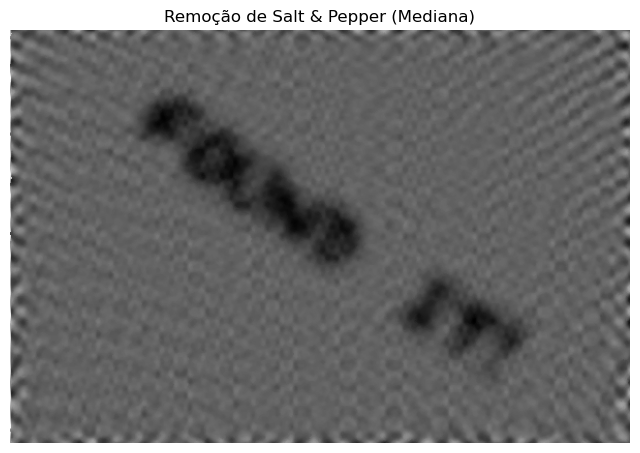

In [8]:
img_limpa = cv2.medianBlur(img_filtrada_freq, MEDIAN_KERNEL_SIZE)
plt.imshow(img_limpa)
plt.title('Remoção de Salt & Pepper (Mediana)')
plt.axis('off')
plt.show()

### Passo 8: Binarização Adaptativa e Contornos

Para finalizar o processo de extração, convertemos a imagem para binário (preto e branco). 

Utilizamos o **Threshold Adaptativo**, que calcula limiares locais para compensar variações de iluminação na imagem. Por fim, aplicamos o detector de bordas de **Canny** para isolar o esqueleto das letras.

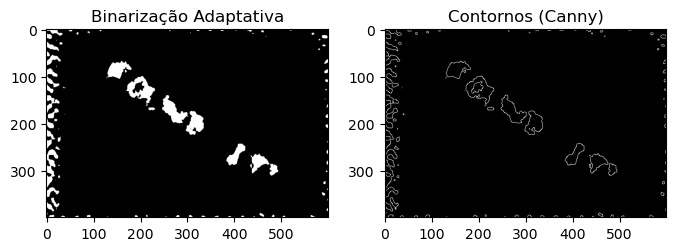

In [9]:
img_binarizada = cv2.adaptiveThreshold(img_limpa, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, ADAPTIVE_BLOCK_SIZE, ADAPTIVE_C)
edges = cv2.Canny(img_binarizada, CANNY_LOW, CANNY_HIGH)

plt.subplot(1, 2, 1), plt.imshow(img_binarizada), plt.title('Binarização Adaptativa')
plt.subplot(1, 2, 2), plt.imshow(edges), plt.title('Contornos (Canny)')
plt.show()

## Conclusões da Primeira Iteração

Esta primeira fase permitiu validar que a filtragem no domínio da frequência era essencial para atacar o ruído periódico presente na imagem. A DFT revelou claramente a existência de frequências parasitas e os filtros notch gaussianos mostraram-se eficazes a atenuá-las sem introduzir transições demasiado bruscas.

Contudo, apesar da melhoria visual obtida após a remoção do ruído periódico e da aplicação do filtro de mediana, a segmentação final ainda apresentou limitações. A binarização adaptativa nem sempre separou corretamente o texto do fundo, e os contornos extraídos não garantiram uma recuperação suficientemente robusta das letras.

Assim, concluímos que:
- a abordagem inicial era promissora para a limpeza estrutural da imagem;
- a fase de segmentação precisava de ser melhorada;
- seria necessário testar técnicas adicionais de realce de contraste e operações morfológicas para aumentar a legibilidade final.

---

# Segunda Iteração: Pipeline Consolidado e Melhorado

Depois da análise da primeira iteração, foi desenvolvida uma abordagem mais completa e robusta. Entre as principais melhorias introduzidas destacam-se:
- melhor parametrização dos filtros notch;
- preservação da componente central do espetro;
- aplicação de filtro de mediana para ruído impulsivo;
- utilização de **CLAHE** para realce de contraste local;
- comparação entre binarização manual e Otsu;
- aplicação de morfologia para limpeza final;
- validação complementar por OCR.

Esta segunda iteração corresponde à abordagem com mais conteúdo e maior nível de detalhe, funcionando como a versão mais rica do trabalho.

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    import pytesseract
    OCR_DISPONIVEL = True
except ImportError:
    OCR_DISPONIVEL = False
    print("Aviso: pytesseract não instalado.")

### Passo 1: Configuração e Parametrização

A modularidade do código é garantida pela definição de parâmetros externos. Isto permite o ajuste fino (*tuning*) das variáveis 'k' (raios, limiares e tamanhos de kernel) sem alterar a lógica interna das funções. 

**Nota:** A escolha dos raios nos filtros Notch (6.0 e 3.0) foi determinada empiricamente para equilibrar a remoção de ruído e a preservação de detalhes das arestas.

In [11]:
INPUT_IMAGE_PATH = '../assets/Letters-noisy.png'
OUTPUT_DIR = '../output/'
SAVE_IMAGES = True  # Flag para controlar a gravação de ficheiros no disco
os.makedirs(OUTPUT_DIR, exist_ok=True)

NOTCH_PASSES = [
    {'threshold_ratio': 0.78, 'radius': 2.0}, # Passagem 1: Ruído dominante
    {'threshold_ratio': 0.65, 'radius': 0.5}  # Passagem 2: Harmónicas secundárias
]
NOTCH_CENTER_PROTECTION = 5 
MEDIAN_KERNEL_SIZE = 3 
CLAHE_CLIP_LIMIT = 1.5 
CLAHE_TILE_GRID_SIZE = (4, 4)
BIN_THRESH_VALUE = 107 
CANNY_THRESH1, CANNY_THRESH2 = 50, 150
KERNEL_SIZE_MORPH = 3

### Passo 2: Aquisição de Dados


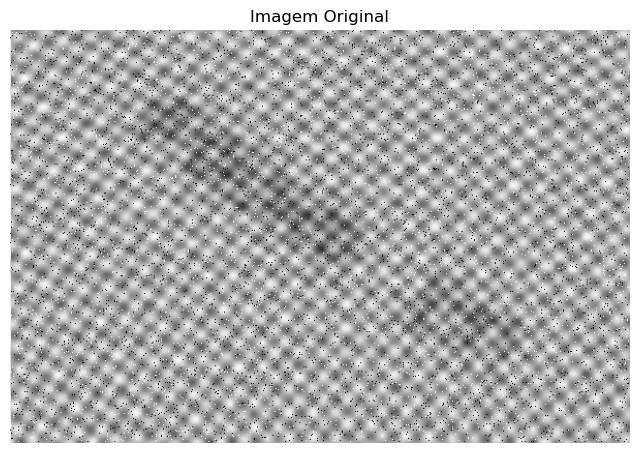

In [12]:
img_original = cv2.imread(INPUT_IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
if SAVE_IMAGES:
    cv2.imwrite(os.path.join(OUTPUT_DIR, '0_original.png'), img_original)

plt.imshow(img_original, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()

### Passo 3: Filtragem Espetral (Ruído Periódico)

O ruído periódico manifesta-se no espetro de magnitude como impulsos de energia fora da origem. 
1. **DFT:** Calculamos a Transformada Discreta de Fourier.
2. **Deteção:** Identificamos os picos que excedem uma percentagem da energia máxima.
3. **Notch Gaussiano:** Aplicamos uma máscara que atenua estas frequências. Protegemos o centro do espetro (DC) para manter o brilho médio da imagem.

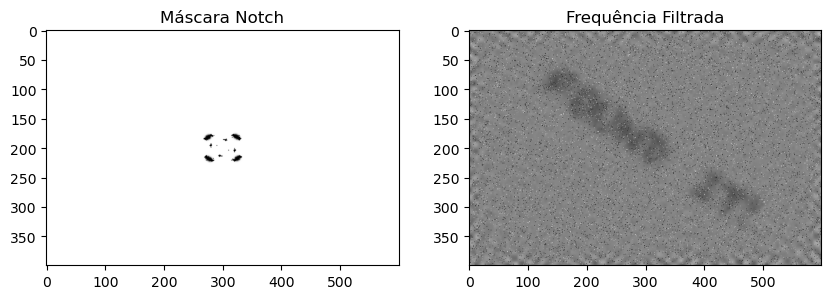

In [13]:
def create_gaussian_notch_mask(shape, center, radius):
    rows, cols = shape
    u, v = np.meshgrid(np.arange(rows), np.arange(cols), indexing='ij')
    d_square = (u - center[0])**2 + (v - center[1])**2
    return 1.0 - np.exp(-d_square / (2 * (radius**2)))

dft_shifted = np.fft.fftshift(np.fft.fft2(img_original.astype(np.float32)))
magnitude_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)
rows, cols = img_original.shape
crow, ccol = rows // 2, cols // 2
combined_mask = np.ones((rows, cols), np.float32)

for p in NOTCH_PASSES:
    thresh = np.max(magnitude_spectrum) * p['threshold_ratio']
    peaks = np.where(magnitude_spectrum > thresh)
    for r, c in zip(peaks[0], peaks[1]):
        if abs(r - crow) > NOTCH_CENTER_PROTECTION or abs(c - ccol) > NOTCH_CENTER_PROTECTION:
            combined_mask *= create_gaussian_notch_mask((rows, cols), (r, c), p['radius'])

img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(dft_shifted * combined_mask)))
img_periodic_removed = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

if SAVE_IMAGES:
    cv2.imwrite(os.path.join(OUTPUT_DIR, '1_periodic_removed.png'), img_periodic_removed)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(combined_mask, cmap='gray'), plt.title('Máscara Notch')
plt.subplot(1, 2, 2), plt.imshow(img_periodic_removed, cmap='gray'), plt.title('Frequência Filtrada')
plt.show()

### Passo 4: Filtragem de Ruído Salt & Pepper

Após a remoção das linhas, a imagem apresenta ruído impulsivo. Aplicamos um **Filtro de Mediana**. Ao contrário de um filtro de média (linear), a mediana é excelente a remover valores atípicos (*outliers*) preservando as descontinuidades (bordas das letras), o que é vital para o passo seguinte de segmentação.

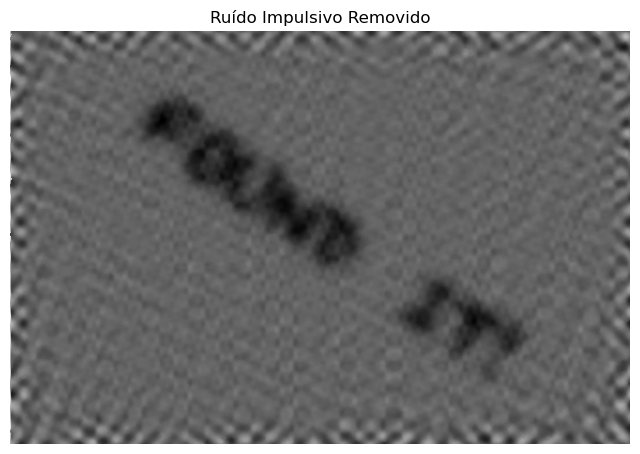

In [14]:
img_denoised = cv2.medianBlur(img_periodic_removed, MEDIAN_KERNEL_SIZE)
if SAVE_IMAGES:
    cv2.imwrite(os.path.join(OUTPUT_DIR, '2_impulsive_removed.png'), img_denoised)

plt.imshow(img_denoised, cmap='gray')
plt.title('Ruído Impulsivo Removido')
plt.axis('off')
plt.show()

### Passo 5: Análise de Histograma e Realce Local (CLAHE)

O histograma da imagem filtrada revela uma distribuição concentrada, indicando baixo contraste. 

Para evidenciar as letras, utilizamos o **CLAHE (Contrast Limited Adaptive Histogram Equalization)**. Diferente da equalização global, o CLAHE opera em pequenas regiões (tiles), aumentando o contraste local sem amplificar excessivamente o ruído remanescente em áreas uniformes.

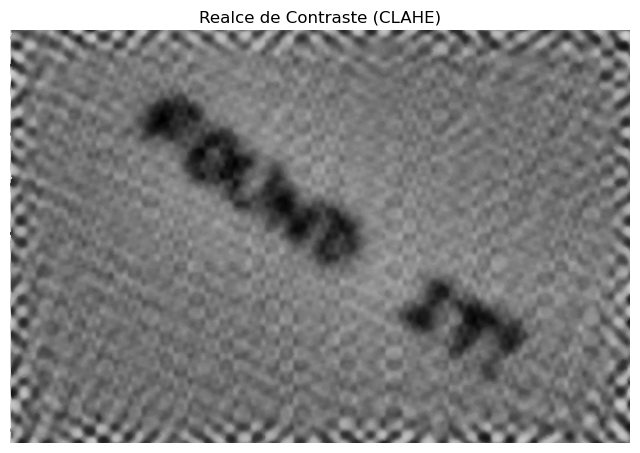

In [15]:
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
img_contrast = clahe.apply(img_denoised)
if SAVE_IMAGES:
    cv2.imwrite(os.path.join(OUTPUT_DIR, '3_contrast_enhanced.png'), img_contrast)

plt.imshow(img_contrast, cmap='gray')
plt.title('Realce de Contraste (CLAHE)')
plt.axis('off')
plt.show()

### Passo 6: Segmentação e Morfologia

Nesta fase, isolamos o texto do fundo. 
1. **Binarização Manual:** Utiliza o valor `BIN_THRESH_VALUE` definido no topo.
2. **Binarização de Otsu:** Determina automaticamente o limiar ótimo para separar as duas classes (texto e fundo).
3. **Morfologia:** Aplicamos uma operação de **Opening** (Erosão seguida de Dilatação) para remover pequenos ruídos que sobreviveram ao processo e separar letras que possam estar ligeiramente fundidas.

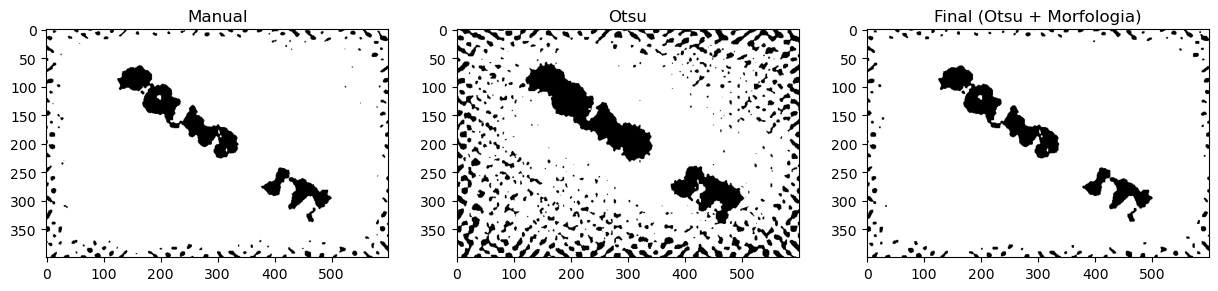

In [16]:
# Binarização Manual
_, img_bin_manual = cv2.threshold(img_contrast, BIN_THRESH_VALUE, 255, cv2.THRESH_BINARY)

# Binarização Otsu
_, img_bin_otsu = cv2.threshold(img_contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (KERNEL_SIZE_MORPH, KERNEL_SIZE_MORPH))
img_final = cv2.morphologyEx(cv2.bitwise_not(img_bin_manual), cv2.MORPH_OPEN, kernel)
img_final = cv2.bitwise_not(img_final)

if SAVE_IMAGES:
    cv2.imwrite(os.path.join(OUTPUT_DIR, '4a_manual_bin.png'), img_bin_manual)
    cv2.imwrite(os.path.join(OUTPUT_DIR, '4b_otsu_bin.png'), img_bin_otsu)
    cv2.imwrite(os.path.join(OUTPUT_DIR, '4c_final_morphology.png'), img_final)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(img_bin_manual, cmap='gray'), plt.title('Manual')
plt.subplot(1, 3, 2), plt.imshow(img_bin_otsu, cmap='gray'), plt.title('Otsu')
plt.subplot(1, 3, 3), plt.imshow(img_final, cmap='gray'), plt.title('Final (Otsu + Morfologia)')
plt.show()

### Passo 7: Deteção de Contornos (Canny)

Aplicamos o algoritmo de Canny para extrair as arestas das letras a partir do resultado morfológico. Este passo é útil para visualizar a estrutura geométrica recuperada.

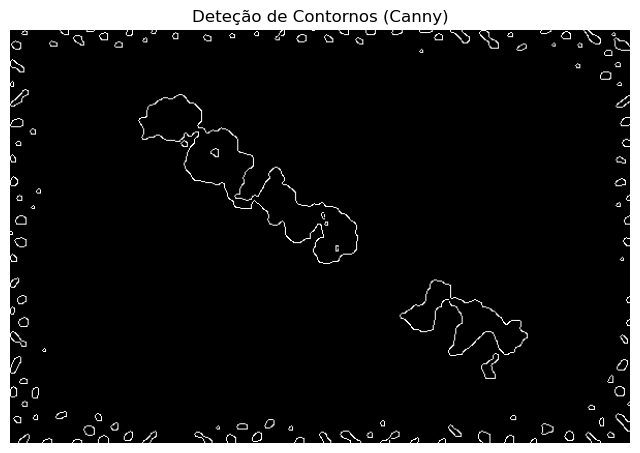

In [17]:
img_edges = cv2.Canny(img_final, CANNY_THRESH1, CANNY_THRESH2)
if SAVE_IMAGES:
    cv2.imwrite(os.path.join(OUTPUT_DIR, '5_canny_edges.png'), img_edges)

plt.imshow(img_edges, cmap='gray')
plt.title('Deteção de Contornos (Canny)')
plt.axis('off')
plt.show()

### Passo 8: Validação por OCR

Como teste final, submetemos a imagem processada ao motor de OCR Tesseract. Embora a degradação original seja extrema, este passo permite avaliar se as formas recuperadas são interpretáveis por algoritmos de visão computacional.

In [18]:
try:
    import pytesseract

    # (Só necessário no Windows — ajusta o caminho se for o teu caso)
    # pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

    # Garantir que o texto está preto em fundo branco
    img_ocr = cv2.bitwise_not(img_final)

    custom_config = r'--oem 3 --psm 6'
    texto = pytesseract.image_to_string(img_ocr, config=custom_config)

    print("\n--- Resultado do OCR ---")
    print(texto.strip() if texto.strip() else "[Nenhum texto detetado]")
    print("------------------------\n")

except ImportError:
    print("pytesseract não está instalado (pip install pytesseract)")
except Exception as e:
    print(f"Erro ao executar OCR: {e}")

Erro ao executar OCR: tesseract is not installed or it's not in your PATH. See README file for more information.


## Conclusão

O projeto demonstrou que a restauração de imagens severamente degradadas exige uma abordagem complexa e nem sempre facil de realizar. 

**Principais Aprendizagens:**
- A **filtragem espetral** é indispensável para ruídos periódicos, onde filtros espaciais falham por não possuírem seletividade de frequência.
- A **não-linearidade** do filtro de mediana foi a chave para limpar o ruído salt & pepper sem destruir a legibilidade dos caracteres.
- O **CLAHE** provou ser superior à equalização global para este caso, pois as letras ocupam áreas locais com iluminação variável.

Os resultados finais mostram letras algumas letras nitidas enquanto outras nem tanto. O Canny parece ter um resultado melhor que nos anteriores, mas mesmo assim ainda longe de ser validado por um OCR. Acreditamos que a resoluçao da imagem, associada com letras mais gordas torne a sua identificaçao dificil devido ao blured gerado. Este liga as imagens e as mesmas apresentao uma coloraçao muto semelhante em toda a sua escrita, talvez se o centro das letras fosse mais escuro, fosse possivel binarizar e ler as letras melhores, tornando-as mais finas.